# 18. Clasificación de textos con bloques Transformer y Embeddings preentrenados

Este notebook resuelve **el mismo problema** que `15_MLP_clasificacion_textos.ipynb`, `16_MLP_Embeddings_clasificacion_textos.ipynb` y `17_LSTM_Embeddings_clasificacion_textos.ipynb`: clasificar el sentimiento de críticas de FilmAffinity en Negativa, Neutra o Positiva. 

Cambiamos otra vez el bloque que procesa la secuencia: en vez de una LSTM, usamos **bloques Transformer**, construidos desde cero con autoatención (*self-attention*), siguiendo los apartados 4.6 y 4.7 de la unidad didáctica (mecanismo de atención y arquitectura Transformer).

La LSTM del notebook 17 procesa la crítica palabra a palabra, de forma estrictamente secuencial: para saber qué pasó en la palabra 200 necesita haber procesado antes, una a una, las 199 anteriores. Esto tiene dos costes: no se puede paralelizar el cálculo dentro de una misma secuencia, y la información de las primeras palabras puede diluirse antes de llegar al final de una crítica larga. Un bloque Transformer sustituye la recurrencia por **autoatención**: cada palabra puede relacionarse directamente con cualquier otra palabra de la crítica en un único paso, sin pasar por los estados intermedios, y todas las palabras se procesan en paralelo.

Reutilizamos tal cual del notebook 17 la carga de datos, la normalización, la partición, la codificación del target, la tokenización a secuencias (mismo `VOCAB_SIZE=20000` y `MAX_LEN=300`) y la construcción de la matriz de embeddings palabra a palabra a partir de `nnlm-es-dim128`, así que esos pasos solo se mencionan de paso. Nos centramos en lo nuevo:

1. Cargar los datos
2. Normalizar los textos
3. Particionado de datos
4. Codificación del target
5. Tokenización a secuencias de enteros y padding
6. Construcción de la matriz de embeddings palabra a palabra desde `nnlm-es-dim128`
7. **Codificación posicional y capa `TokenAndPositionEmbedding`** 
8. **Bloque Transformer** (atención + red *feed-forward* + conexiones residuales)
9. **Máscara de padding para la atención** 
10. Definición de la Red Neuronal completa
11. Entrenamiento de la Red Neuronal
12. Evaluación del modelo, comparando con los notebooks 15, 16 y 17

---

## 1. Carga de datos


In [1]:
import warnings
warnings.filterwarnings('ignore')

import logging

class SilenciaDeprecados(logging.Filter):
    '''Filtra el WARNING de tf.losses.sparse_softmax_cross_entropy que se dispara durante el propio import de TensorFlow.'''
    def filter(self, record):
        return 'deprecated' not in record.getMessage()

logging.getLogger('tensorflow').addFilter(SilenciaDeprecados())

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'       # silencia mensajes informativos de TensorFlow
os.environ['TF_USE_LEGACY_KERAS'] = '1'        # necesario para usar hub.KerasLayer (ver seccion 6)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

import pandas as pd

df = pd.read_csv('corpus/reviews_filmaffinity.csv', sep='\|\|', engine='python')
df = df.dropna(subset=['review_rate'])
df['texto'] = df['review_title'].fillna('') + '. ' + df['review_text'].fillna('')

def nota_a_sentimiento(nota):
    if nota <= 4:
        return 'Negativa'
    elif nota <= 6:
        return 'Neutra'
    else:
        return 'Positiva'

df['sentimiento'] = df['review_rate'].apply(nota_a_sentimiento)

print(f'Total de criticas: {len(df)}')
print(df['sentimiento'].value_counts())

Total de criticas: 8601
sentimiento
Positiva    3920
Negativa    2447
Neutra      2234
Name: count, dtype: int64


---

## 2. Normalización de los textos

Normalización ligera (minúsculas y espacios limpios).

In [2]:
def normalizar(texto):
    '''Normalizacion ligera para embeddings: solo minusculas y espacios limpios (ver notebook 14).'''
    return ' '.join(texto.strip().lower().split())

X = [normalizar(texto) for texto in df['texto'].tolist()]
y = df['sentimiento'].tolist()

print('Original:   ', df['texto'].iloc[0][:200], '...')
print('\nNormalizado:', X[0][:200], '...')

Original:    OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO. La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...

Normalizado: ocho apellidos vascos...y ningún nombre propio. la mayor virtud de esta película es su existencia.el hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...


---

## 3. Particionado de datos (Train y Test)

Partición aleatoria estratificada, 80 % de entrenamiento y 20 % de test.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Criticas de entrenamiento: {len(X_train)}')
print(f'Criticas de test:          {len(X_test)}')

Criticas de entrenamiento: 6880
Criticas de test:          1721


---

## 4. Codificación del target

`LabelEncoder` sobre el sentimiento.

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(y_train)
y_train_enc = encoder.transform(y_train)
y_test_enc  = encoder.transform(y_test)

print(f'Clases codificadas: {list(encoder.classes_)}')

Clases codificadas: [np.str_('Negativa'), np.str_('Neutra'), np.str_('Positiva')]


---

## 5. Tokenización a secuencias de enteros y padding

`Tokenizer` ajustado solo con `X_train`, con (`VOCAB_SIZE = 20000`) y (`MAX_LEN = 300`), para que la comparación con la LSTM del notebook 17 sea lo más controlada posible.

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000   # palabras mas frecuentes que conservamos (igual que en el notebook 17)
MAX_LEN = 300         # longitud maxima de secuencia (igual que en el notebook 17)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulario real (incluye <OOV>): {len(tokenizer.word_index) + 1} palabras distintas, usaremos las {VOCAB_SIZE} mas frecuentes')
print(f'Forma de X_train_pad: {X_train_pad.shape}')

Vocabulario real (incluye <OOV>): 56168 palabras distintas, usaremos las 20000 mas frecuentes
Forma de X_train_pad: (6880, 300)


---

## 6. Construcción de la matriz de embeddings palabra a palabra desde `nnlm-es-dim128`

Construimos una matriz `(VOCAB_SIZE + 1, 128)` pidiéndole al módulo el vector de cada palabra del vocabulario del `Tokenizer`.

In [6]:
import tensorflow_hub as hub

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}' + (f' -> {gpus}' if gpus else ' -> se entrenara en CPU'))

modulo_embeddings = hub.load('https://tfhub.dev/google/nnlm-es-dim128/2')

VOCAB_REAL = min(VOCAB_SIZE, len(tokenizer.word_index)) + 1   # +1 por el indice 0 (padding)
EMBED_DIM = 128

palabras_por_indice = [''] * VOCAB_REAL
for palabra, indice in tokenizer.word_index.items():
    if indice < VOCAB_REAL:
        palabras_por_indice[indice] = palabra

embedding_matrix = np.zeros((VOCAB_REAL, EMBED_DIM), dtype='float32')

LOTE = 2000
for inicio in range(1, VOCAB_REAL, LOTE):   # empezamos en 1: la fila 0 (padding) se queda a cero
    fin = min(inicio + LOTE, VOCAB_REAL)
    lote_palabras = [p if p else '<OOV>' for p in palabras_por_indice[inicio:fin]]
    embedding_matrix[inicio:fin] = modulo_embeddings(lote_palabras).numpy()

print(f'Matriz de embeddings: {embedding_matrix.shape}')

GPUs disponibles: 0 -> se entrenara en CPU
Matriz de embeddings: (20001, 128)


---

## 7. Codificación posicional y capa `TokenAndPositionEmbedding`

La LSTM del notebook 17 conoce el orden de las palabras, porque las procesa una a una, en orden. La autoatención, en cambio, mira **todas las palabras de golpe**: por sí sola, no tiene ninguna forma de distinguir "el perro muerde al cartero" de "el cartero muerde al perro", porque ambas frases contienen las mismas palabras, solo que en distinto orden.

Para solucionarlo, antes de entrar al primer bloque Transformer, a cada palabra se le suma un **vector de posición** que depende únicamente de en qué lugar de la secuencia está esa palabra (posición 0, 1, 2...), no de qué palabra es. Así, la misma palabra en dos posiciones distintas de la crítica entra a la red con un vector ligeramente distinto, y el orden pasa a formar parte de la información de entrada.

La capa `TokenAndPositionEmbedding` combina las dos piezas:

- **Embedding de token**: la matriz `embedding_matrix` de la sección 6 (una fila por palabra del vocabulario).
- **Embedding de posición**: una capa `Embedding` nueva, con una fila por cada posible posición (`0` a `MAX_LEN - 1`), inicializada aleatoriamente y **aprendida durante el entrenamiento**.

La salida es, para cada palabra, la suma de su embedding de token y su embedding de posición — misma forma que la matriz de entrada, `(MAX_LEN, 128)`, pero ahora con el orden incorporado.

In [7]:
from tensorflow.keras.layers import Layer, Embedding


class TokenAndPositionEmbedding(Layer):
    '''Suma el embedding de la palabra (token) con el embedding de su posicion en la secuencia.'''

    def __init__(self, max_len, vocab_size, embed_dim, embedding_matrix=None, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        pesos_iniciales = [embedding_matrix] if embedding_matrix is not None else None
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim,
                                    weights=pesos_iniciales, trainable=True)
        self.pos_emb = Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        longitud = tf.shape(x)[-1]
        posiciones = tf.range(start=0, limit=longitud, delta=1)
        posiciones = self.pos_emb(posiciones)
        tokens = self.token_emb(x)
        return tokens + posiciones

    def get_config(self):
        # No serializamos embedding_matrix (es solo el peso inicial): model.save()
        # ya guarda los pesos aprendidos de self.token_emb por su cuenta.
        config = super().get_config()
        config.update({'max_len': self.max_len, 'vocab_size': self.vocab_size, 'embed_dim': self.embed_dim})
        return config


# Comprobacion rapida: la salida tiene forma (batch, MAX_LEN, EMBED_DIM)
capa_prueba = TokenAndPositionEmbedding(MAX_LEN, VOCAB_REAL, EMBED_DIM, embedding_matrix)
salida_prueba = capa_prueba(X_train_pad[:2])
print('Forma de salida de TokenAndPositionEmbedding:', salida_prueba.shape)

Forma de salida de TokenAndPositionEmbedding: (2, 300, 128)


---

## 8. Bloque Transformer

Un **bloque Transformer** combina la autoatención con una red *feed-forward*, cada una envuelta en una **conexión residual** seguida de una normalización (*Add & Norm*):

1. **Autoatención multicabeza** sobre la entrada, seguida de `Dropout` y de `x + atención(x)` (conexión residual) y una `LayerNormalization`.
2. **Red *feed-forward*** (dos capas `Dense`: una que expande la dimensión y aplica `relu`, otra que la vuelve a comprimir a `embed_dim`) aplicada de forma independiente a cada palabra, seguida de `Dropout` y de otra conexión residual + `LayerNormalization`.

La idea del reparto de tareas es: la atención "mezcla" información entre palabras (cada una recoge contexto de las demás); la red *feed-forward* "interpreta" esa información en cada palabra por separado, de forma no lineal. La conexión residual (sumar la entrada a la salida de la subcapa) facilita que el gradiente fluya durante el entrenamiento, lo que permite apilar varios bloques sin que el aprendizaje se degrade.

Como la entrada y la salida de un bloque tienen la **misma forma** (`MAX_LEN × embed_dim`), se pueden apilar varios bloques uno detrás de otro: la salida de uno es la entrada del siguiente. Usamos **2 bloques** apilados.

In [8]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Dense
from tensorflow.keras import Sequential as KerasSequential


class TransformerBlock(Layer):
    '''Autoatencion multicabeza + red feed-forward, cada una con conexion residual y LayerNormalization.'''

    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = KerasSequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, x, attention_mask=None, training=False):
        attn_output = self.att(query=x, value=x, key=x, attention_mask=attention_mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'dropout_rate': self.dropout_rate,
        })
        return config


# Comprobacion rapida sobre la salida de TokenAndPositionEmbedding
bloque_prueba = TransformerBlock(embed_dim=EMBED_DIM, num_heads=8, ff_dim=256)
salida_bloque = bloque_prueba(salida_prueba)
print('Forma de salida del TransformerBlock (igual que la entrada):', salida_bloque.shape)

Forma de salida del TransformerBlock (igual que la entrada): (2, 300, 128)


---

## 9. Máscara de padding para la atención

Falta un último detalle antes de montar la red completa. La LSTM del notebook 17 usaba `mask_zero=True` en la capa `Embedding`, y Keras se encargaba automáticamente de que la LSTM ignorase las posiciones de *padding* (índice 0) al recorrer la secuencia paso a paso.

La autoatención no tiene ese mecanismo automático: si no le decimos nada, cada palabra "prestará atención" también a las posiciones de relleno, como si fueran palabras reales, contaminando la representación final. Por eso construimos explícitamente una **máscara de padding**: un valor `True` en las posiciones con una palabra real y `False` en las de relleno, que se pasa a `MultiHeadAttention` para que esas posiciones no participen ni como *Query* ni como *Key*/*Value* relevantes, y también se usa al final para promediar solo sobre las posiciones reales al resumir la secuencia en un único vector (sección 11).

In [9]:
def crear_mascara_padding(secuencias):
    '''Devuelve un booleano por posicion: True si la palabra es real, False si es padding (indice 0).'''
    return tf.not_equal(secuencias, 0)

mascara_ejemplo = crear_mascara_padding(X_train_pad[:1])
print('Palabras reales en la primera critica de entrenamiento:', int(tf.reduce_sum(tf.cast(mascara_ejemplo, tf.int32))), 'de', MAX_LEN)

Palabras reales en la primera critica de entrenamiento: 267 de 300


---

## 10. Definición de la Red Neuronal completa

Con las piezas ya construidas, montamos la red. A diferencia de los notebooks 15, 16 y 17, que usaban `Sequential` (una pila lineal de capas), aquí usamos la **API funcional** de Keras, porque necesitamos pasar la misma máscara de padding tanto a los bloques Transformer (para la atención) como al resumen final de la secuencia — algo que no se puede expresar con una simple pila de capas.

La arquitectura es:

1. **`TokenAndPositionEmbedding`**: convierte la secuencia de enteros en su representación con orden incorporado (sección 7).
2. **2 bloques `TransformerBlock`** apilados (sección 8), cada uno recibiendo la máscara de padding (sección 9) para que la atención ignore el relleno.
3. **Promedio enmascarado** (*masked average pooling*): la salida de los bloques Transformer sigue siendo una secuencia (`MAX_LEN × 128`, una fila por palabra); para clasificar necesitamos un único vector por crítica, así que promediamos las filas, pero solo las de posiciones reales (usando la máscara), igual que hicimos manualmente al principio de la sección 9.
4. **Red clasificadora**: igual que en los notebooks 15, 16 y 17 — `Dropout` 20 %, 32 neuronas `relu`, `Dropout` 20 % y 3 neuronas de salida con `softmax`.

In [ ]:
from tensorflow.keras import Input, Model

EMBED_DIM = 128
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOQUES = 2

tf.keras.utils.set_random_seed(42)   # fija a la vez las semillas de Python, NumPy y TensorFlow (np.random.seed no basta: la inicializacion de pesos usa el generador propio de TF)
tf.config.experimental.enable_op_determinism()   # evita variaciones por el orden de operaciones en coma flotante entre ejecuciones

entradas = Input(shape=(MAX_LEN,), dtype='int32')
mascara = crear_mascara_padding(entradas)                      # (batch, MAX_LEN)
mascara_atencion = mascara[:, tf.newaxis, :]                    # (batch, 1, MAX_LEN), se difunde a (batch, MAX_LEN, MAX_LEN)

x = TokenAndPositionEmbedding(MAX_LEN, VOCAB_REAL, EMBED_DIM, embedding_matrix)(entradas)
for _ in range(NUM_BLOQUES):
    x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM, dropout_rate=0.1)(x, attention_mask=mascara_atencion)

mascara_float = tf.cast(mascara, tf.float32)[:, :, tf.newaxis]  # (batch, MAX_LEN, 1)
x = tf.reduce_sum(x * mascara_float, axis=1) / tf.reduce_sum(mascara_float, axis=1)   # promedio enmascarado
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)
salidas = Dense(3, activation='softmax')(x)

model = Model(entradas, salidas)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

---

## 11. Entrenamiento de la Red Neuronal

Aplicamos el mismo procedimiento que en los notebooks 15, 16 y 17: `class_weight` para compensar el desbalanceo de clases, y el mismo *callback* `F1Checkpoint` que registra el F1 ponderado de train y test en cada epoch y guarda en un único fichero el modelo con mejor F1 de test.

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score

pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = {clase: peso for clase, peso in zip(np.unique(y_train_enc), pesos)}
print('Pesos por clase:', class_weight_dict)


class F1Checkpoint(Callback):
    '''Igual que en los notebooks 15, 16 y 17: registra el F1 ponderado de train/test y guarda el mejor modelo.'''

    def __init__(self, filepath, X_train, y_train_enc, X_val, y_val_enc):
        super().__init__()
        self.filepath = filepath
        self.X_train = X_train
        self.y_train_enc = y_train_enc
        self.X_val = X_val
        self.y_val_enc = y_val_enc
        self.best_f1 = -1.0
        self.f1_train_history = []
        self.f1_val_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_train_enc = np.argmax(self.model.predict(self.X_train, verbose=0), axis=-1)
        y_pred_val_enc   = np.argmax(self.model.predict(self.X_val, verbose=0), axis=-1)

        f1_train = f1_score(self.y_train_enc, y_pred_train_enc, average='weighted')
        f1_val   = f1_score(self.y_val_enc, y_pred_val_enc, average='weighted')

        self.f1_train_history.append(f1_train)
        self.f1_val_history.append(f1_val)

        if f1_val > self.best_f1:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> mejora, guardando modelo en {self.filepath}')
            self.best_f1 = f1_val
            self.model.save(self.filepath)
        else:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> no mejora el mejor val_f1 ({self.best_f1:.4f})')


MODEL_PATH = 'models/18_mejor_modelo_transformer_reviews.keras'
os.makedirs('models', exist_ok=True)

checkpoint_f1 = F1Checkpoint(
    filepath=MODEL_PATH,
    X_train=X_train_pad, y_train_enc=y_train_enc,
    X_val=X_test_pad, y_val_enc=y_test_enc
)

Pesos por clase: {np.int64(0): np.float64(1.1718616930676204), np.int64(1): np.float64(1.2833426599515017), np.int64(2): np.float64(0.7312925170068028)}


In [12]:
history = model.fit(
    X_train_pad, y_train_enc,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_data=(X_test_pad, y_test_enc),
    class_weight=class_weight_dict,
    callbacks=[checkpoint_f1]
)

history.history['f1'] = checkpoint_f1.f1_train_history
history.history['val_f1'] = checkpoint_f1.f1_val_history

Epoch 1/5
108/108 [==============================] - ETA: 0s - loss: 1.1116 - accuracy: 0.3574
Epoch 1: f1: 0.2854 - val_f1: 0.2852 -> mejora, guardando modelo en models/18_mejor_modelo_transformer_reviews.keras
108/108 [==============================] - 144s 1s/step - loss: 1.1116 - accuracy: 0.3574 - val_loss: 1.0837 - val_accuracy: 0.4555
Epoch 2/5
108/108 [==============================] - ETA: 0s - loss: 0.9631 - accuracy: 0.5390
Epoch 2: f1: 0.6006 - val_f1: 0.5746 -> mejora, guardando modelo en models/18_mejor_modelo_transformer_reviews.keras
108/108 [==============================] - 156s 1s/step - loss: 0.9631 - accuracy: 0.5390 - val_loss: 0.8529 - val_accuracy: 0.6020
Epoch 3/5
108/108 [==============================] - ETA: 0s - loss: 0.7109 - accuracy: 0.7073
Epoch 3: f1: 0.8320 - val_f1: 0.6529 -> mejora, guardando modelo en models/18_mejor_modelo_transformer_reviews.keras
108/108 [==============================] - 141s 1s/step - loss: 0.7109 - accuracy: 0.7073 - val_loss

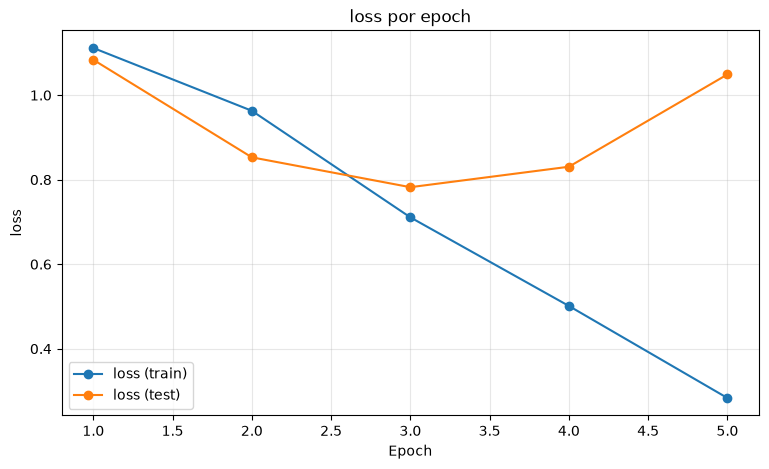

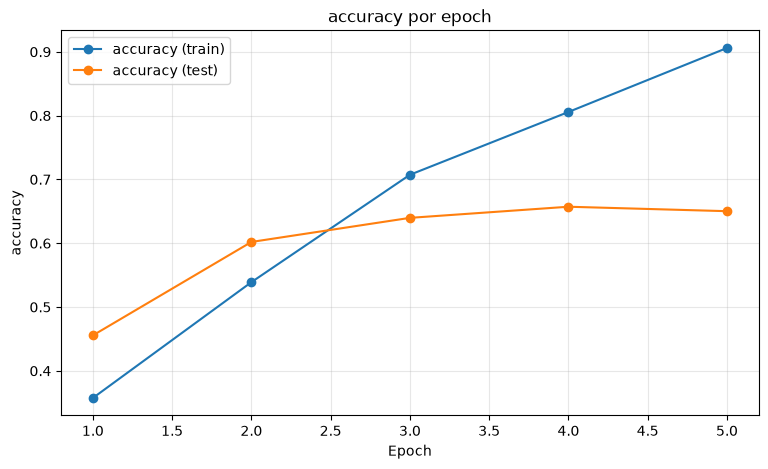

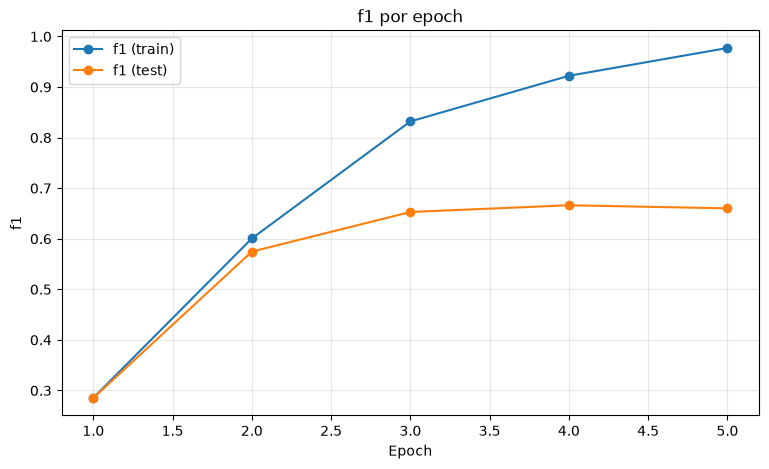

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(history, name):
    metric_train = history.history[name]
    metric_test  = history.history[f'val_{name}']
    epochs_range = range(1, len(metric_train) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, metric_train, marker='o', label=f'{name} (train)')
    plt.plot(epochs_range, metric_test, marker='o', label=f'{name} (test)')
    plt.title(f'{name} por epoch')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history, 'loss')
plot_metric(history, 'accuracy')
plot_metric(history, 'f1')

---

## 12. Evaluación del modelo

Igual que en los notebooks 15, 16 y 17, cargamos desde disco el modelo del epoch con mejor F1 de test y evaluamos con él.

In [14]:
from tensorflow.keras.models import load_model

modelo_transformer = load_model(MODEL_PATH,
                                custom_objects={'TokenAndPositionEmbedding': TokenAndPositionEmbedding, 'TransformerBlock': TransformerBlock})
print(f'Modelo cargado desde: {MODEL_PATH}')

Modelo cargado desde: models/18_mejor_modelo_transformer_reviews.keras


In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)

y_pred_test_enc  = np.argmax(modelo_transformer.predict(X_test_pad), axis=-1)
y_pred_train_enc = np.argmax(modelo_transformer.predict(X_train_pad), axis=-1)

y_pred_test  = encoder.inverse_transform(y_pred_test_enc)
y_pred_train = encoder.inverse_transform(y_pred_train_enc)

print('--- Evaluacion en TEST ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_test, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_test))

215/215 [==============================] - 23s 109ms/step
--- Evaluacion en TEST ---
Accuracy:  0.6572
Precision: 0.7069
Recall:    0.6572
F1:        0.6663

              precision    recall  f1-score   support

    Negativa       0.81      0.51      0.63       490
      Neutra       0.43      0.64      0.52       447
    Positiva       0.80      0.76      0.78       784

    accuracy                           0.66      1721
   macro avg       0.68      0.64      0.64      1721
weighted avg       0.71      0.66      0.67      1721



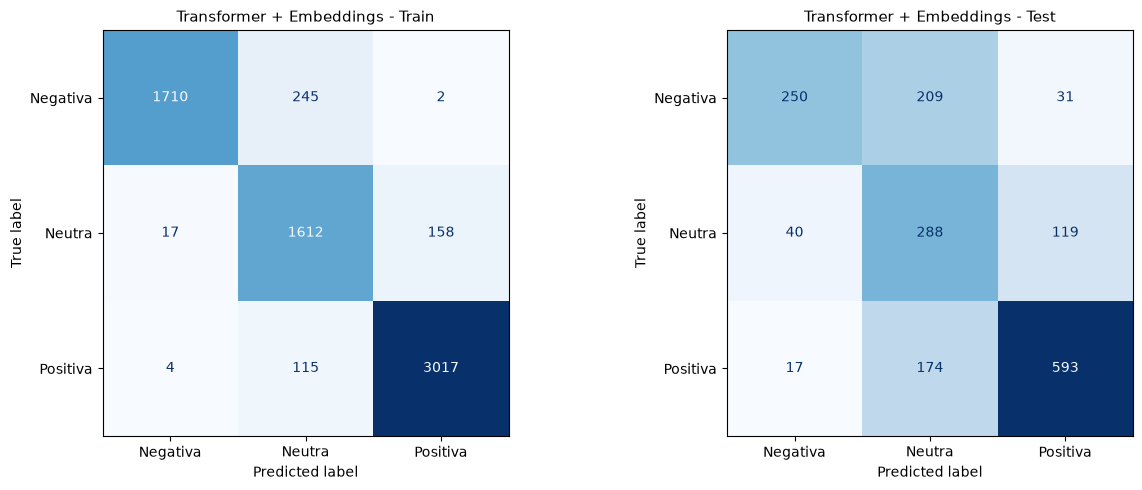

In [16]:
clases = list(encoder.classes_)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Transformer + Embeddings - Train', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[1])
axes[1].set_title('Transformer + Embeddings - Test', fontsize=11)

plt.tight_layout()
plt.show()

## Conclusiones

* El `F1Checkpoint` se quedó con el modelo del **epoch 4** (val_f1 = 0.6663), el mejor de los 5 epochs entrenados. El F1 de entrenamiento sube muy rápido, de 0.29 en el epoch 1 a 0.98 en el epoch 5, mientras que el F1 de test deja de mejorar en el epoch 4 y cae en el epoch 5 (0.66): con solo 5 epochs ya se aprecia el mismo patrón de sobreajuste rápido que en los notebooks anteriores, a pesar del `Dropout` que hay tanto dentro de cada bloque Transformer como en la red clasificadora final.

* El modelo cargado desde disco (el del epoch 4) obtiene en test un **accuracy del 65.72 % y un F1 ponderado de 0.6663**, con un F1 por clase de 0.63 (Negativa), 0.52 (Neutra) y 0.78 (Positiva):

    | Notebook | Representación | Accuracy | F1 | F1 Negativa | F1 Neutra | F1 Positiva |
    |---|---|---|---|---|---|---|
    | 15 | Bag of Words (3.000 dim.) | 67.46 % | 0.6712 | 0.70 | 0.47 | 0.77 |
    | **16** | **Embedding `nnlm-es-dim128` (documento)** | **68.56 %** | **0.6869** | 0.69 | 0.52 | 0.78 |
    | 17 | Embedding `nnlm-es-dim128` (por palabra) + LSTM bidireccional | 67.34 % | 0.6833 | 0.69 | 0.52 | 0.77 |
    | 18 | Embedding `nnlm-es-dim128` (por palabra) + 2 bloques Transformer | 65.72 % | 0.6663 | 0.63 | 0.52 | 0.78 |

* MLP, LSTM y Transformer son formas distintas de procesar la misma representación de entrada, cada una con sus propias ventajas (paralelización, forma de capturar dependencias entre palabras, etc.) y su propio coste en parámetros y decisiones de diseño — no tiene sentido decir que una sea mejor que otra en general. En este problema concreto, con unas 6.880 críticas de entrenamiento, el resultado del Transformer queda por debajo de los otros tres. Es razonable pensar que se debe a que su arquitectura es la más compleja de las cuatro (autoatención multicabeza más una red *feed-forward* en cada uno de los 2 bloques apilados, con más hiperparámetros que ajustar: número de cabezas, dimensión de la red *feed-forward*, número de bloques), y ese margen de maniobra adicional puede favorecer el sobreajuste sobre este volumen de datos antes de que llegue a traducirse en una ventaja real.

* El F1 de la clase Neutra (0.52) iguala al mejor valor visto hasta ahora, y el de Positiva (0.78) está en línea con el resto; la diferencia principal está en Negativa, donde el Transformer se queda claramente por debajo (0.63 frente a 0.69-0.70 en los demás notebooks): la precisión en esa clase es alta (0.81), pero el recall es bajo (0.51), es decir, el modelo se vuelve más conservador a la hora de predecir Negativa y deja sin identificar bastantes críticas negativas reales.

* Esto no significa que los bloques Transformer sean una arquitectura "peor" — son la base de los modelos de lenguaje que dominan el NLP actual, y están pensados para escalar con arquitecturas mucho más profundas y con volúmenes de datos muy superiores a los de este notebook. Lo que muestra este resultado es que, con un conjunto de datos relativamente pequeño como el de aquí, una arquitectura más compleja no garantiza por sí sola un mejor resultado: hace falta suficiente cantidad de datos para que esa complejidad adicional se traduzca en una ventaja real en lugar de en sobreajuste.